**Assignment - Section 5 - Core Data Libraries in Python**

### **Titanic Dataset Exploration (Self Evaluation)**

### **What to do:**
- Load the dataset and explore it step by step.
- Load the Titanic dataset using Pandas
- Inspect the shape, columns, and basic information
- Check for missing values and handle them appropriately
- Find how many passengers survived and did not survive
- Analyze survival based on gender
- Analyze survival based on passenger class
- Find the average age and average fare
- Create simple visualizations to support your findings

In [2]:
# %pip install -U -q seaborn

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load the dataset
path = r"C:\Users\Benny\Machine-Learning-Bootcamp\titanic.csv"
titanic_df = pd.read_csv(path)

# titanic_df = sns.load_dataset("titanic")

In [5]:
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [6]:
# Dataframe shape
titanic_df.shape

(891, 12)

In [7]:
titanic_df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [8]:
titanic_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
titanic_df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [10]:
# Fill the missing age row with average age
# Drop the cabin column
# Fill the embarked with the column mode

In [11]:
titanic_df.columns = [x.title() for x in titanic_df.columns]
titanic_df.columns

Index(['Passengerid', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Sibsp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [12]:
# Fill Age with mean
titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].mean())

In [13]:
# Fill Embarked with mode (most frequent value)
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

In [14]:
# Drop Cabin column
titanic_df.drop(columns='Cabin', inplace=True)

In [15]:
titanic_df.isnull().sum()

Passengerid    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
Sibsp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

C:\Users\Benny\AppData\Local\Temp\ipykernel_10640\544471959.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survival_count.index,


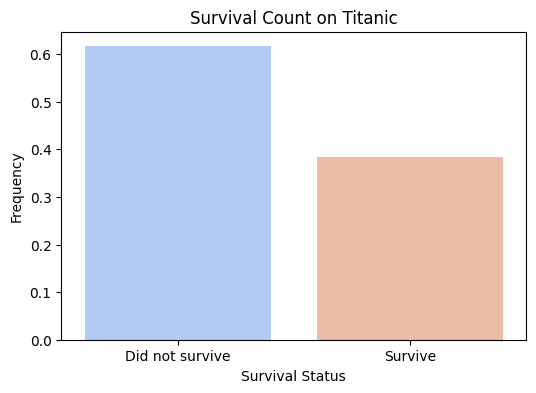

In [64]:
# Passengers Survival Rate
survival_count = titanic_df['Survived'].value_counts(normalize=True)
survival_count.index = ["Did not survive", "Survive"]

plt.figure(figsize=(6, 4))
sns.barplot(x=survival_count.index,
            y=survival_count.values, palette="coolwarm")

plt.title("Survival Count on Titanic")
plt.xlabel("Survival Status")
plt.ylabel("Frequency")

plt.show()

C:\Users\Benny\AppData\Local\Temp\ipykernel_10640\3430911325.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=survived_gender.index, y = survived_gender.values, palette="coolwarm")


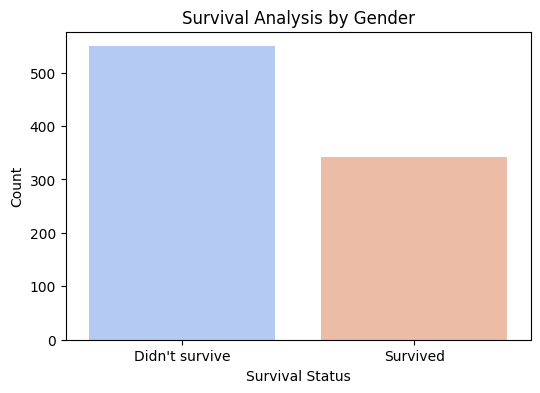

In [69]:
# - Analyze survival based on gender
survived_gender = titanic_df.groupby(titanic_df["Survived"])["Sex"].count()
survived_gender.index = ["Didn't survive", "Survived"]

plt.figure(figsize=(6, 4))
sns.barplot(x=survived_gender.index, y = survived_gender.values, palette="coolwarm")
plt.xlabel("Survival Status")
plt.ylabel("Count")
plt.title("Survival Analysis by Gender")
plt.show()

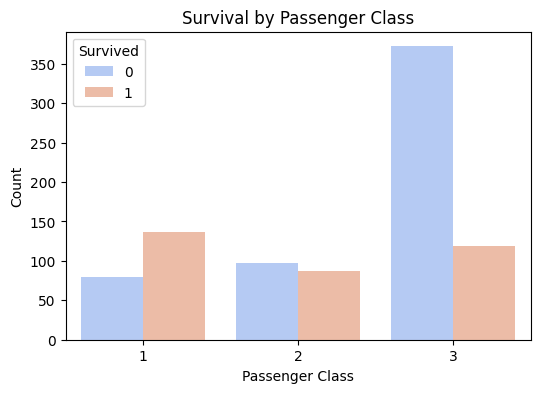

In [76]:
pd.crosstab(titanic_df['Pclass'], titanic_df['Survived'])

plt.figure(figsize=(6, 4))
sns.countplot(x="Pclass", hue="Survived", data=titanic_df, palette="coolwarm")

plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.title("Survival by Passenger Class")
plt.show()

In [ ]:
# - Find the average age and average fare
avg = titanic_df[["Age", "Fare"]].mean()

C:\Users\Benny\AppData\Local\Temp\ipykernel_10640\67604370.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg.index, y=avg.values, palette="coolwarm")


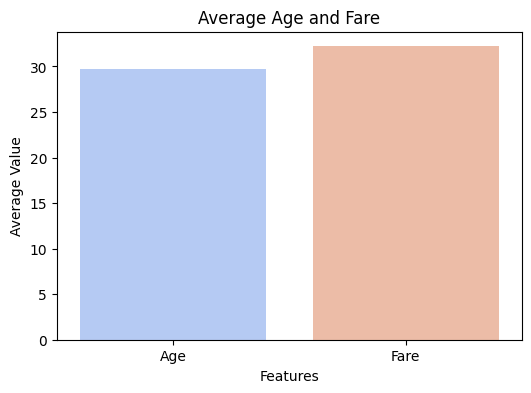

In [79]:
plt.figure(figsize=(6, 4))
sns.barplot(x=avg.index, y=avg.values, palette="coolwarm")

plt.title("Average Age and Fare")
plt.xlabel("Features")
plt.ylabel("Average Value")

plt.show()